# Projeto 2 — Osciladores Acoplados
**Física Computacional · LEFT 2025/2026**

Exploração do comportamento de uma cadeia linear de $N$ massas ligadas por $N-1$ molas,
com possibilidade de ligação a paredes nos extremos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.4, 'lines.linewidth': 1.8, 'font.size': 11})

## Método de Euler

O método de Euler resolve numericamente EDOs do tipo $y' = f(x, y)$, $y(x_0)=y_0$:

$$y_{n+1} = y_n + h\,f(x_n, y_n)$$

Validamos a implementação na EDO $\dfrac{dy}{dx} = xy$, condição inicial $y(0) = 1$,
cuja solução analítica é $y(x) = e^{x^2/2}$.

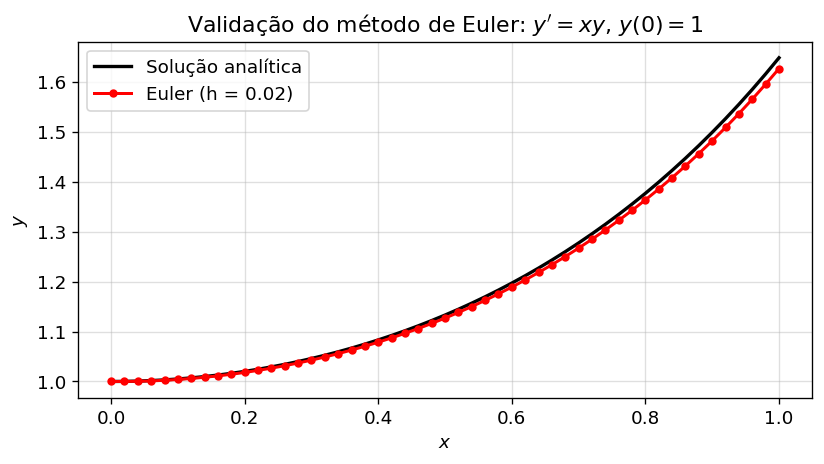

In [2]:
def metodo_euler(f, t0, y0, t_final, h):
    """
    Resolve a EDO y' = f(x, y) pelo metodo de Euler explicito.
    f       : funcao f(x, y) que define a EDO
    t0      : abcissa inicial
    y0      : condicao inicial y(t0)
    t_final : abcissa final
    h       : passo de integracao
    """
    X = np.arange(t0, t_final + h, h)
    Y = np.zeros(len(X))
    Y[0] = y0
    for i in range(len(X) - 1):
        Y[i+1] = Y[i] + h * f(X[i], Y[i])
    return X, Y

def eq_dif(x, y):
    return x * y

def sol_analitica(x):
    return np.exp(x**2 / 2)

X = np.arange(0, 1 + 0.02, 0.02)
x_euler, y_euler = metodo_euler(eq_dif, 0, 1, 1, 0.02)

plt.figure(figsize=(7, 4))
plt.plot(X, sol_analitica(X), 'k-', lw=2, label='Solução analítica')
plt.plot(x_euler, y_euler, 'ro-', ms=4, label='Euler (h = 0.02)')
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title("Validação do método de Euler: $y'=xy$, $y(0)=1$")
plt.legend(); plt.tight_layout(); plt.show()

## 1) Implementação do sistema

O sistema de $N$ massas acopladas obedece a $\mathbf{M}\ddot{\mathbf{x}} = -\mathbf{K}\mathbf{x}$.
Convertendo para $2N$ EDOs de 1.ª ordem com $\mathbf{u}(t) = [\mathbf{x}(t),\mathbf{v}(t)]^T$:

$$\dot{\mathbf{u}}(t) = \mathbf{A}\,\mathbf{u}(t), \qquad
\mathbf{A} = \begin{bmatrix} \mathbf{0} & \mathbf{I} \\\\ -\mathbf{M}^{-1}\mathbf{K} & \mathbf{0} \end{bmatrix}$$

A classe `Coupled_Oscillators` implementa este sistema, resolvendo por dois métodos:
o método de Euler explícito e `scipy.integrate.solve_ivp` (DOP853, ordem 8).

In [3]:
class Coupled_Oscillators:
    def __init__(self, N, m=1.0, k_springs=1.0, left_wall_k=0.0, right_wall_k=0.0):
        """
        Inicializa o sistema de N osciladores acoplados.
        N (int)              : numero de massas
        m (float ou array)   : massa(s); float -> todas iguais
        k_springs (float ou array): constantes das N-1 molas internas
        left_wall_k (float)  : mola na parede esquerda (0 = sem parede)
        right_wall_k (float) : mola na parede direita  (0 = sem parede)
        """
        self.N = N
        self.M = self._build_mass_matrix(m)
        self.K = self._build_K_matrix(k_springs, left_wall_k, right_wall_k)

    # -- 1a: matriz de massa
    def _build_mass_matrix(self, m):
        """Constroi M = diag(m_1,...,m_N). m pode ser float ou array de N valores."""
        if np.isscalar(m):
            masses = np.full(self.N, float(m))
        else:
            masses = np.asarray(m, dtype=float)
            if len(masses) != self.N:
                raise ValueError(f'm deve ter {self.N} elementos, tem {len(masses)}.')
        return np.diag(masses)

    # -- 1b: matriz K
    def _build_K_matrix(self, k_springs, left_wall_k, right_wall_k):
        """Constroi a matriz K tridiagonal (equacao 4 da ficha)."""
        N = self.N
        if np.isscalar(k_springs):
            k = np.full(N - 1, float(k_springs))
        else:
            k = np.asarray(k_springs, dtype=float)
            if len(k) != N - 1:
                raise ValueError(f'k_springs deve ter {N-1} elementos, tem {len(k)}.')
        K = np.zeros((N, N))
        for i in range(N):
            if i == 0:      K[i, i] = left_wall_k + k[0]
            elif i == N-1:  K[i, i] = k[N-2] + right_wall_k
            else:           K[i, i] = k[i-1] + k[i]
        for i in range(N - 1):
            K[i, i+1] = -k[i]
            K[i+1, i] = -k[i]
        return K

    # -- Matriz A do sistema de 1.a ordem
    def _build_A_matrix(self):
        """Constroi A (2N x 2N): u_dot = A u."""
        N = self.N
        MinvK = np.diag(1.0 / np.diag(self.M)) @ self.K
        return np.block([[np.zeros((N, N)), np.eye(N)],
                         [-MinvK,          np.zeros((N, N))]])

    # -- 1c: Euler
    def solve_coupled_system_linear_Euler(self, x0=None, v0=None, t_max=50, num_points=1000):
        """
        Resolve o sistema de 2N EDOs pelo metodo de Euler explicito.
        Extensao vectorial do metodo_euler() definido acima.
        Retorna: sol_euler_t (T,)  e  sol_euler_u (2N, T)
        """
        N = self.N
        if x0 is None: x0 = np.zeros(N)
        if v0 is None: v0 = np.zeros(N)
        A  = self._build_A_matrix()
        u0 = np.concatenate([x0, v0])
        sol_euler_t = np.linspace(0, t_max, num_points)
        dt          = t_max / (num_points - 1)
        sol_euler_u = np.zeros((2*N, num_points))
        sol_euler_u[:, 0] = u0
        for i in range(num_points - 1):
            sol_euler_u[:, i+1] = sol_euler_u[:, i] + dt * (A @ sol_euler_u[:, i])
        return sol_euler_t, sol_euler_u

    # -- 1c: solve_ivp
    def solve_coupled_system_linear_numpy(self, x0=None, v0=None, t_max=50, num_points=1000):
        """
        Resolve o sistema de 2N EDOs com scipy.integrate.solve_ivp (DOP853, ordem 8).
        Retorna: sol_t (T,)  e  sol_u (2N, T)
        """
        N = self.N
        if x0 is None: x0 = np.zeros(N)
        if v0 is None: v0 = np.zeros(N)
        A      = self._build_A_matrix()
        u0     = np.concatenate([x0, v0])
        t_eval = np.linspace(0, t_max, num_points)
        sol = solve_ivp(lambda t, u: A @ u, [0, t_max], u0,
                        method='DOP853', t_eval=t_eval, rtol=1e-10, atol=1e-12)
        return sol.t, sol.y

    # -- Energias
    def kinetic_energy(self, u):
        """T(t) = 0.5 * v^T M v para cada instante. u: (2N, T)."""
        v = u[self.N:]
        return 0.5 * np.einsum('i,it->t', np.diag(self.M), v**2)

    def potential_energy(self, u):
        """V(t) = 0.5 * x^T K x para cada instante. u: (2N, T)."""
        x = u[:self.N]
        return 0.5 * np.einsum('it,ij,jt->t', x, self.K, x)

    # -- Modos normais
    def normal_modes(self):
        """
        Modos normais e frequencias proprias via numpy.linalg.
        Transforma K eta = lambda M eta em problema simetrico A xi = lambda xi
        com A = M^{-1/2} K M^{-1/2}, resolvido por numpy.linalg.eigh.
        eta_j = M^{-1/2} xi_j  (M-ortonormais: eta_j^T M eta_k = delta_jk)
        Retorna: omegas (N,) e modes (N, N) com colunas = modos normais.
        """
        m_diag     = np.diag(self.M)
        M_sqrt_inv = np.diag(1.0 / np.sqrt(m_diag))
        A_sym      = M_sqrt_inv @ self.K @ M_sqrt_inv
        lambdas, xi = np.linalg.eigh(A_sym)
        return np.sqrt(np.abs(lambdas)), M_sqrt_inv @ xi

    # -- Sobreposição de modos normais
    def solve_normal_modes(self, x0, v0, t_eval):
        """
        Solucao analitica exacta por sobreposicao linear:
        x(t) = sum_j [(eta_j^T M x0) cos(w_j t) + (eta_j^T M v0 / w_j) sin(w_j t)] eta_j
        Retorna: x_t (N, T)  e  v_t (N, T)
        """
        omegas, modes = self.normal_modes()
        N, T = self.N, len(t_eval)
        x_t = np.zeros((N, T));  v_t = np.zeros((N, T))
        for j in range(N):
            eta = modes[:, j]
            Cj  = eta @ self.M @ x0
            Sj  = eta @ self.M @ v0
            om  = omegas[j]
            if om < 1e-12:
                x_t += np.outer(eta, Cj + Sj*t_eval)
                v_t += np.outer(eta, np.full(T, Sj))
            else:
                x_t += np.outer(eta, Cj*np.cos(om*t_eval) + (Sj/om)*np.sin(om*t_eval))
                v_t += np.outer(eta, -Cj*om*np.sin(om*t_eval) + Sj*np.cos(om*t_eval))
        return x_t, v_t

### Verificação das matrizes

Verificamos $\mathbf{M}$ e $\mathbf{K}$ para um sistema assimétrico ($N=3$, massas e
molas distintas), confirmando a equação (4) da ficha.

In [4]:
osc_test = Coupled_Oscillators(3, m=[1.0, 2.0, 1.0], k_springs=[1.5, 2.0],
                               left_wall_k=1.0, right_wall_k=1.0)
print('M ='); print(osc_test.M)
print('K ='); print(osc_test.K)
# Esperado: K = [[2.5, -1.5, 0], [-1.5, 3.5, -2], [0, -2, 3]]

M =
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]
K =
[[ 2.5 -1.5  0. ]
 [-1.5  3.5 -2. ]
 [ 0.  -2.   3. ]]


## 2) Simulação

### 2a) Sistema com 5 massas — massa central deslocada

Sistema com $N=5$, $m_i=1.0$ kg, $k_{ij}=1.0$ N/m, $k_L=k_R=1.0$ N/m.
Condição inicial: apenas $m_3$ deslocada de $x_3(0)=1.0$ m, velocidades nulas.

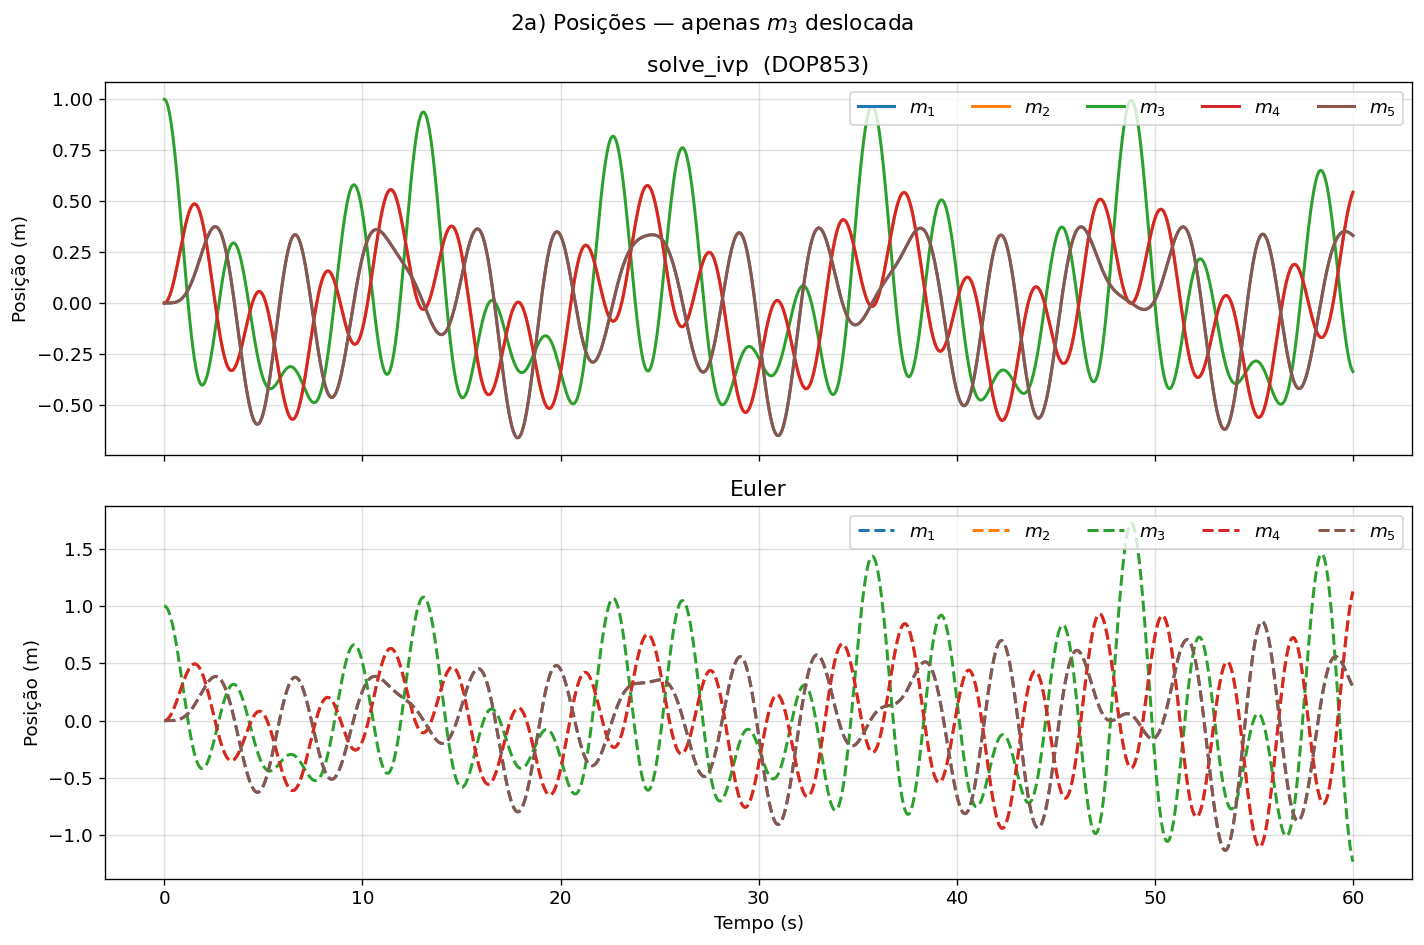

In [5]:
N     = 5
m_val = 1.0   # kg
k_val = 1.0   # N/m
kW    = 1.0   # constante das molas nas paredes

osc = Coupled_Oscillators(N, m=m_val, k_springs=k_val,
                          left_wall_k=kW, right_wall_k=kW)

x0_2a = np.zeros(N);  x0_2a[2] = 1.0
v0_2a = np.zeros(N)

t_max      = 60.0
num_points = 6000   # dt = 0.01 s

t_ivp,   u_ivp   = osc.solve_coupled_system_linear_numpy(x0_2a, v0_2a, t_max, num_points)
t_euler, u_euler = osc.solve_coupled_system_linear_Euler(x0_2a, v0_2a, t_max, num_points)

colors = plt.cm.tab10(np.linspace(0, 0.5, N))
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for i in range(N):
    axes[0].plot(t_ivp,   u_ivp[i],   color=colors[i], label=f'$m_{i+1}$')
    axes[1].plot(t_euler, u_euler[i], color=colors[i], label=f'$m_{i+1}$', ls='--')
for ax, title in zip(axes, ['solve_ivp  (DOP853)', 'Euler']):
    ax.set_ylabel('Posição (m)'); ax.set_title(title); ax.legend(ncol=5, loc='upper right')
axes[1].set_xlabel('Tempo (s)')
fig.suptitle('2a) Posições — apenas $m_3$ deslocada', fontsize=13)
plt.tight_layout(); plt.show()

**Análise:** $m_3$ está no centro do sistema simétrico, pelo que excita apenas os
**modos simétricos** (modos 1, 3 e 5) com **amplitudes iguais**
($|\boldsymbol{\eta}_j^T\mathbf{M}\mathbf{x}_0| \approx 0.577$ para os três modos).
A sobreposição das três frequências $\omega_1, \omega_3, \omega_5$ produz movimento
**quasi-periódico**: existem três frequências de batimento independentes,
$\omega_3-\omega_1$, $\omega_5-\omega_3$ e $\omega_5-\omega_1$, que em geral são
incomensuráveis — o padrão de batimento não se repete exactamente.

O Euler acumula erros de fase e amplitude crescentes, divergindo da solução correcta
para $t \gtrsim 20$ s.

### 2b) Todas as massas deslocadas igualmente

Condição inicial: $x_i(0) = 1.0$ m para todo $i$, velocidades nulas.

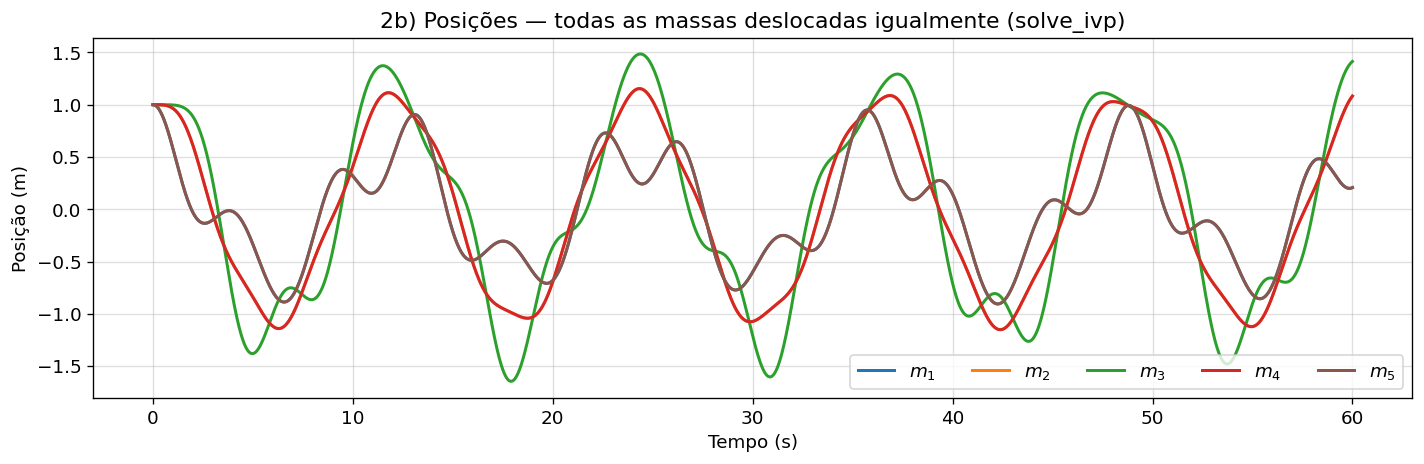

Intervalo de variacao da posicao de cada massa:
  m1: [1.0000,  -0.9056] m
  m2: [1.1537,  -1.1517] m
  m3: [1.4852,  -1.6455] m
  m4: [1.1537,  -1.1517] m
  m5: [1.0000,  -0.9056] m


In [6]:
x0_2b = np.ones(N)
v0_2b = np.zeros(N)

t_ivp_b, u_ivp_b = osc.solve_coupled_system_linear_numpy(x0_2b, v0_2b, t_max, num_points)

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(N):
    ax.plot(t_ivp_b, u_ivp_b[i], color=colors[i], label=f'$m_{i+1}$')
ax.set_xlabel('Tempo (s)'); ax.set_ylabel('Posição (m)')
ax.set_title('2b) Posições — todas as massas deslocadas igualmente (solve_ivp)')
ax.legend(ncol=5); plt.tight_layout(); plt.show()

print('Intervalo de variacao da posicao de cada massa:')
for i in range(N):
    print(f'  m{i+1}: [{u_ivp_b[i].max():.4f},  {u_ivp_b[i].min():.4f}] m')

**Análise:** O deslocamento uniforme $\mathbf{x}_0=[1,1,1,1,1]^T$ **não é um modo normal**
— verifica-se que $\mathbf{K}\mathbf{x}_0=[1,0,0,0,1]^T\neq\lambda\mathbf{x}_0$
para qualquer $\lambda$. Projecta-se apenas nos modos simétricos (1, 3, 5) com amplitudes
nas proporções $\approx 14:3.7:1$, pelo que o modo 1 domina fortemente.

**Diferença em relação a 2a:** em 2a os três modos simétricos têm amplitudes iguais,
produzindo **batimento forte** com transferência evidente entre massas. Em 2b o modo 1
domina: o movimento parece quase periódico, mas as amplitudes não são constantes
(a tabela acima mostra que $m_2$ e $m_4$ excedem 1 m, confirmando um **batimento fraco**
entre os modos 1, 3 e 5).

### 2c) Conservação de energia

Energia cinética: $T = \tfrac{1}{2}\mathbf{v}^T\mathbf{M}\mathbf{v}$;  
Energia potencial: $V = \tfrac{1}{2}\mathbf{x}^T\mathbf{K}\mathbf{x}$;  
Energia total: $E = T + V = $ constante (sistema conservativo).

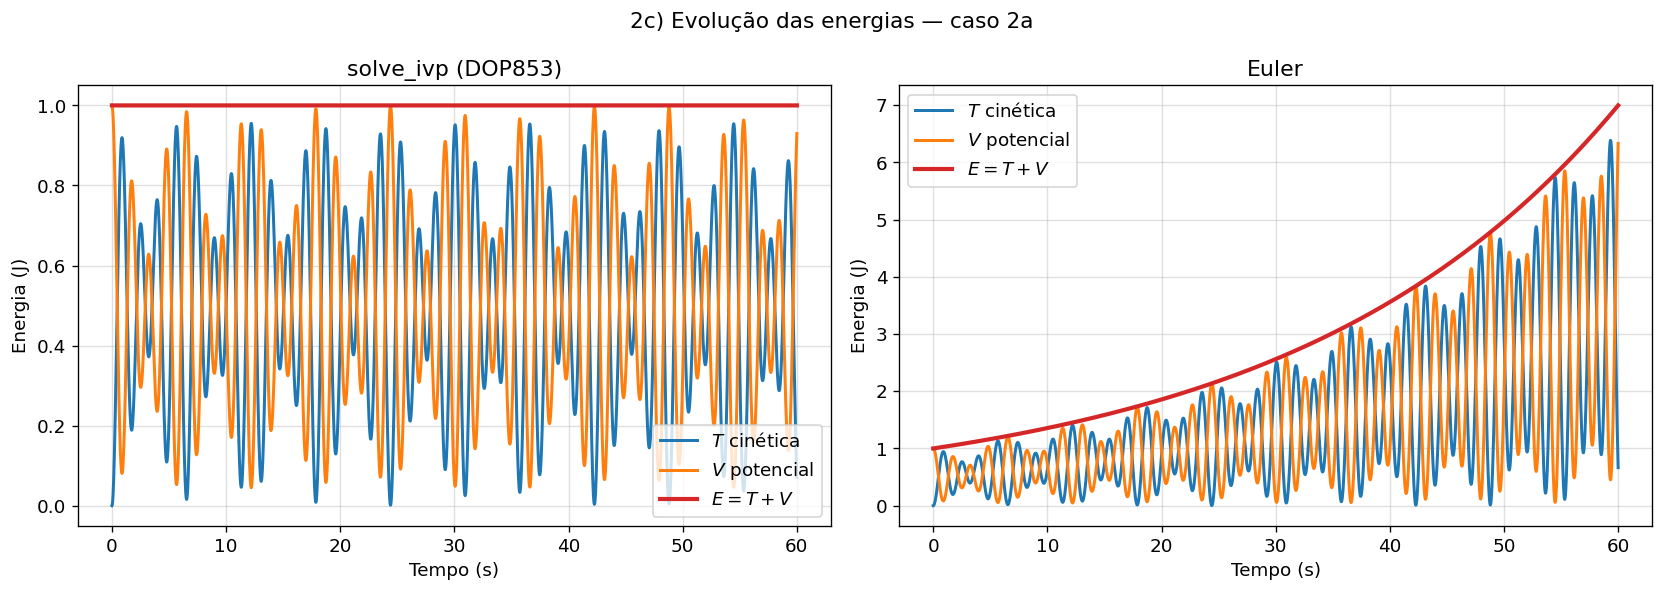

solve_ivp — desvio relativo maximo de E: 4.82e-10
Euler     — desvio relativo maximo de E: 6.00e+00


In [7]:
T_ivp   = osc.kinetic_energy(u_ivp);   V_ivp   = osc.potential_energy(u_ivp)
T_euler = osc.kinetic_energy(u_euler); V_euler = osc.potential_energy(u_euler)
E_ivp   = T_ivp + V_ivp;              E_euler = T_euler + V_euler

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, T, V, E, label in [
    (axes[0], t_ivp,   T_ivp,   V_ivp,   E_ivp,   'solve_ivp (DOP853)'),
    (axes[1], t_euler, T_euler, V_euler, E_euler, 'Euler'),
]:
    ax.plot(t, T, label='$T$ cinética',  color='tab:blue')
    ax.plot(t, V, label='$V$ potencial', color='tab:orange')
    ax.plot(t, E, label='$E = T+V$',     color='tab:red', lw=2.5)
    ax.set_xlabel('Tempo (s)'); ax.set_ylabel('Energia (J)')
    ax.set_title(label); ax.legend()
fig.suptitle('2c) Evolução das energias — caso 2a', fontsize=13)
plt.tight_layout(); plt.show()

E0 = E_ivp[0]
print(f'solve_ivp — desvio relativo maximo de E: {np.max(np.abs(E_ivp - E0))/E0:.2e}')
print(f'Euler     — desvio relativo maximo de E: {np.max(np.abs(E_euler - E_euler[0]))/E_euler[0]:.2e}')

**Análise:** O Euler é **instável em energia**: sendo explícito de 1.ª ordem, não preserva
a estrutura Hamiltoniana e a energia cresce sem limite (desvio de 600%).
O DOP853 conserva a energia com desvio relativo $< 10^{-9}$, compatível com
`rtol=1e-10`, `atol=1e-12`.

## 3) Modos Normais

### 3a) Frequências e modos normais

Substituindo $\mathbf{x}(t)=\boldsymbol{\eta}e^{i\omega t}$ na equação de movimento,
obtem-se o problema de valores próprios:

$$\mathbf{M}^{-1}\mathbf{K}\,\boldsymbol{\eta}_j = \lambda_j\boldsymbol{\eta}_j,
\qquad \lambda_j = \omega_j^2$$

Resolve-se transformando em problema standard simétrico com `numpy.linalg.eigh`:
$\mathbf{A}=\mathbf{M}^{-1/2}\mathbf{K}\mathbf{M}^{-1/2}$,
$\boldsymbol{\eta}_j=\mathbf{M}^{-1/2}\boldsymbol{\xi}_j$ (M-ortonormais).

Frequencias proprias:
  omega_1 = 0.517638 rad/s   T_1 = 12.1382 s
  omega_2 = 1.000000 rad/s   T_2 = 6.2832 s
  omega_3 = 1.414214 rad/s   T_3 = 4.4429 s
  omega_4 = 1.732051 rad/s   T_4 = 3.6276 s
  omega_5 = 1.931852 rad/s   T_5 = 3.2524 s


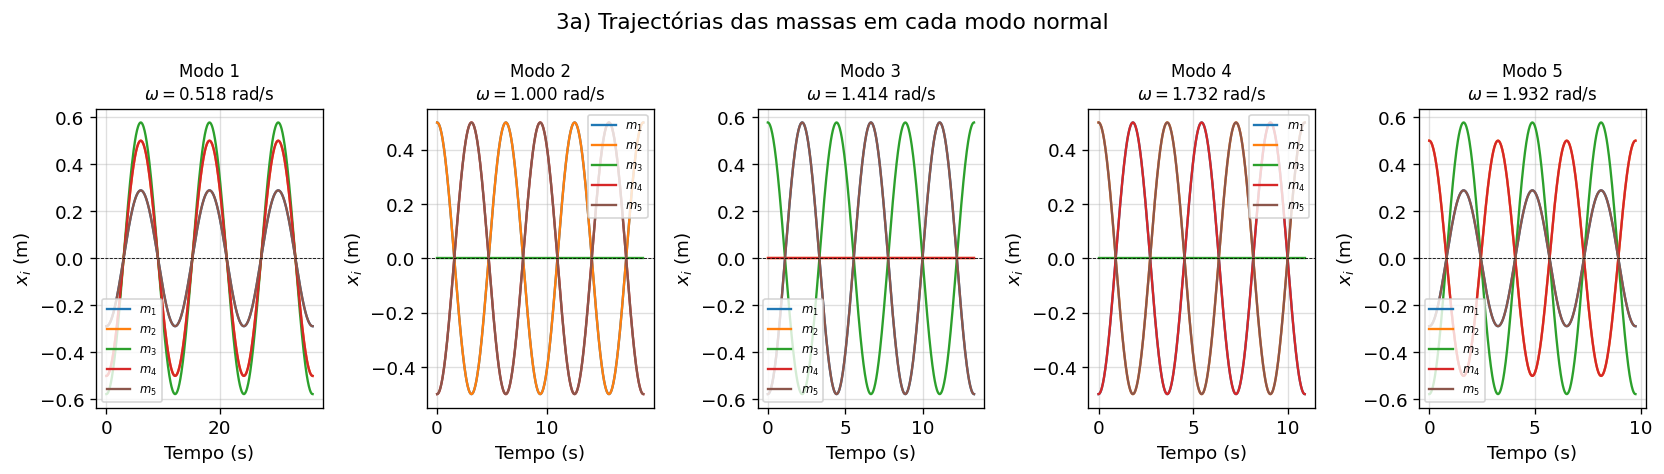

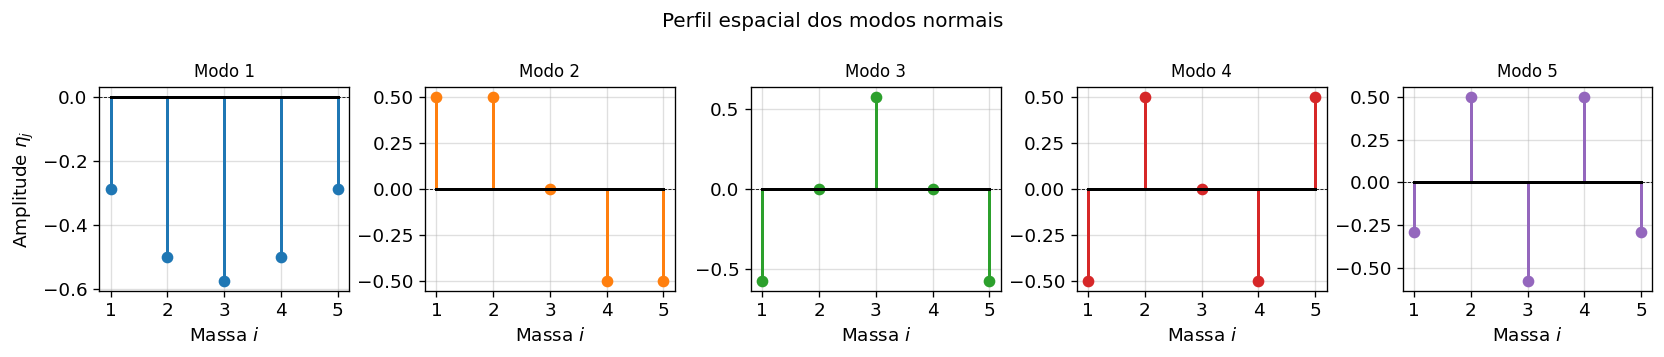

In [8]:
omegas, modes = osc.normal_modes()

print('Frequencias proprias:')
for j, w in enumerate(omegas):
    print(f'  omega_{j+1} = {w:.6f} rad/s   T_{j+1} = {2*np.pi/w:.4f} s')

# Trajectórias: x_i(t) = eta_j[i] * cos(omega_j * t) para excitacao pura do modo j
fig, axes = plt.subplots(1, N, figsize=(14, 4))
for j in range(N):
    ax  = axes[j]
    t_m = np.linspace(0, 3 * 2*np.pi/omegas[j], 600)   # 3 periodos
    for i in range(N):
        ax.plot(t_m, modes[i, j] * np.cos(omegas[j]*t_m),
                color=colors[i], label=f'$m_{i+1}$', lw=1.4)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel('Tempo (s)'); ax.set_ylabel('$x_i$ (m)')
    ax.set_title(f'Modo {j+1}\n$\\omega={omegas[j]:.3f}$ rad/s', fontsize=10)
    ax.legend(fontsize=7)
fig.suptitle('3a) Trajectórias das massas em cada modo normal', fontsize=13)
plt.tight_layout(); plt.show()

# Perfil espacial (amplitude de cada massa)
fig, axes = plt.subplots(1, N, figsize=(14, 3))
for j in range(N):
    ax = axes[j]
    ax.stem(range(1, N+1), modes[:, j], basefmt='k-',
            linefmt=f'C{j}-', markerfmt=f'C{j}o')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_title(f'Modo {j+1}', fontsize=10); ax.set_xlabel('Massa $i$')
    if j == 0: ax.set_ylabel('Amplitude $\\eta_j$')
    ax.set_xticks(range(1, N+1))
fig.suptitle('Perfil espacial dos modos normais', fontsize=12)
plt.tight_layout(); plt.show()

**Análise:** Em cada modo normal todas as massas oscilam à mesma frequência $\omega_j$
— distinguem-se apenas pelas amplitudes e fases relativas (visíveis nos perfis espaciais).

- **Modos simétricos** (1, 3, 5): $\eta_i = \eta_{N+1-i}$. Modo 1: todas as massas em
  fase, amplitude máxima no centro. Modos 3, 5: nós internos crescentes.
- **Modos anti-simétricos** (2, 4): $\eta_i = -\eta_{N+1-i}$, nó obrigatório em $m_3$.

As frequências satisfazem exactamente
$\omega_j = 2\sqrt{k/m}\,|\sin(j\pi/(2(N+1)))|$ para $k_W=k=m=1$.

### 3b) Solução por sobreposição de modos normais

A solução geral é a sobreposição:

$$\mathbf{x}(t) = \sum_{j=1}^{N}\left[
  (\boldsymbol{\eta}_j^T\mathbf{M}\mathbf{x}_0)\cos(\omega_j t)
  + \frac{\boldsymbol{\eta}_j^T\mathbf{M}\mathbf{v}_0}{\omega_j}\sin(\omega_j t)
\right]\boldsymbol{\eta}_j$$

Comparamos com os dois métodos numéricos da parte 1.

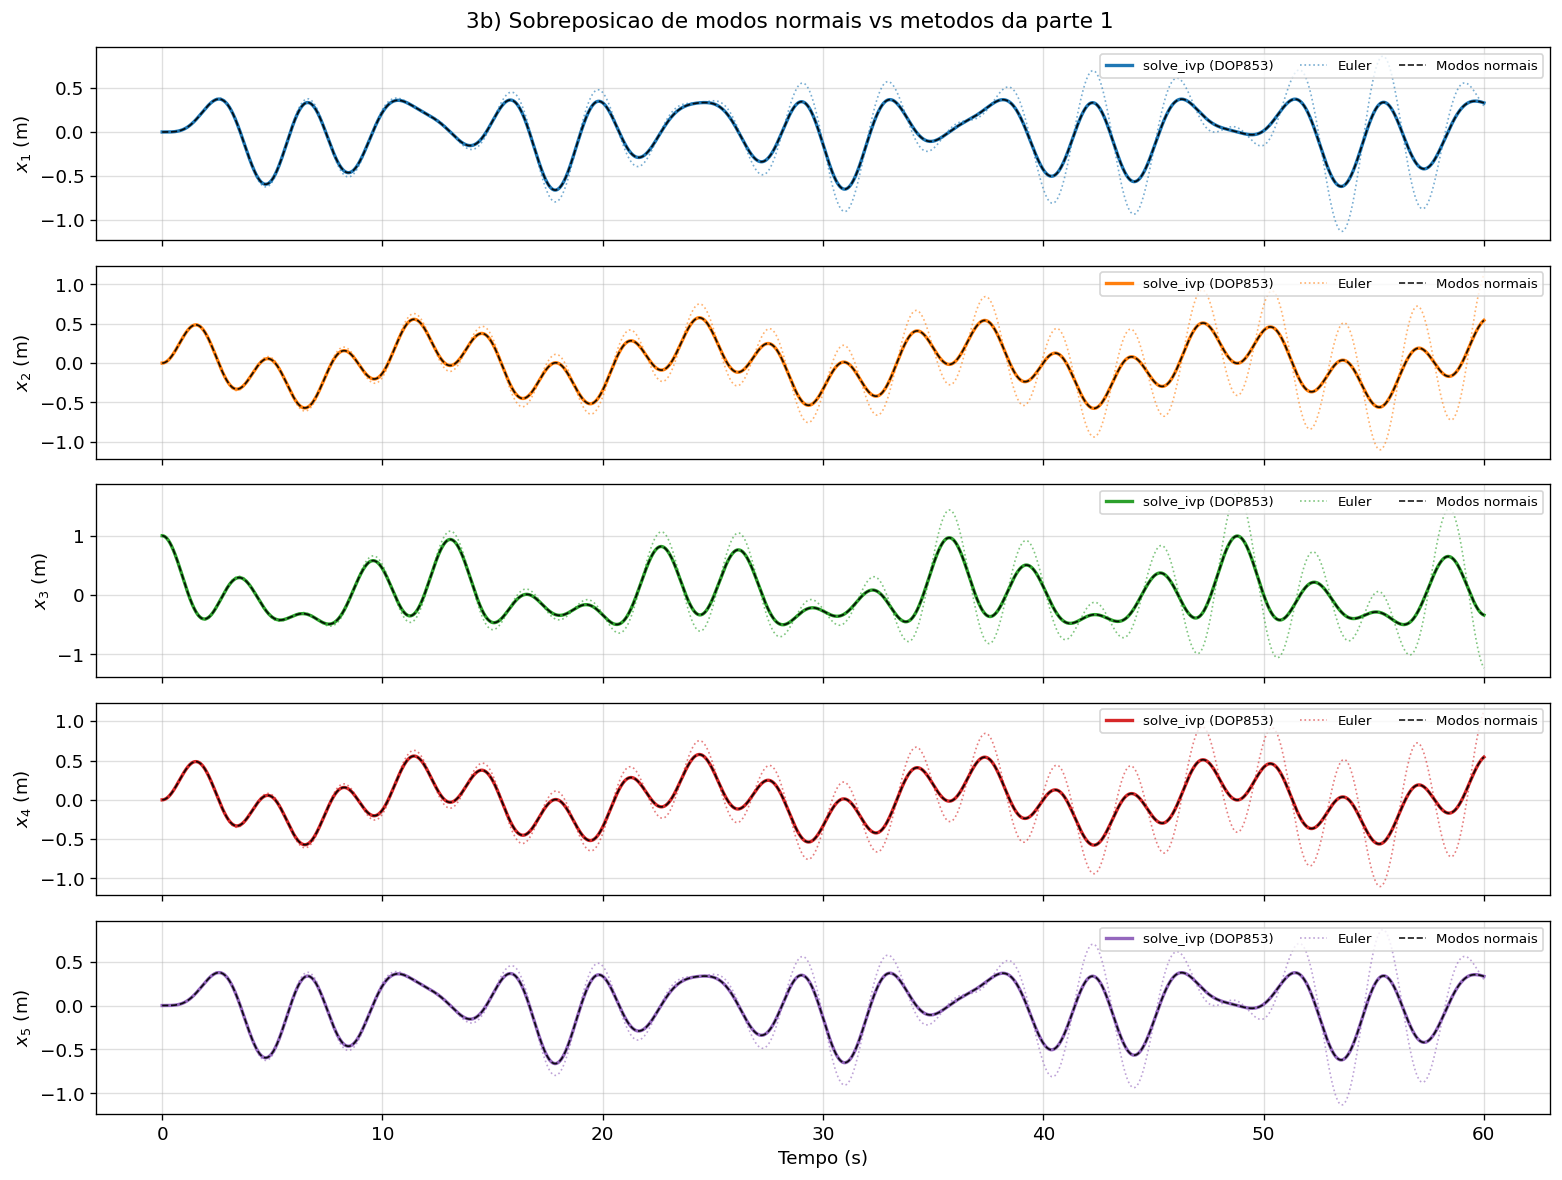

Erro absoluto maximo:
  m1:  modos vs DOP853 = 1.26e-10 m   |   modos vs Euler = 5.26e-01 m
  m2:  modos vs DOP853 = 2.11e-10 m   |   modos vs Euler = 5.82e-01 m
  m3:  modos vs DOP853 = 2.54e-10 m   |   modos vs Euler = 8.94e-01 m
  m4:  modos vs DOP853 = 2.11e-10 m   |   modos vs Euler = 5.82e-01 m
  m5:  modos vs DOP853 = 1.26e-10 m   |   modos vs Euler = 5.26e-01 m


In [9]:
t_eval = np.linspace(0, t_max, num_points)
x_nm, _ = osc.solve_normal_modes(x0_2a, v0_2a, t_eval)

fig, axes = plt.subplots(N, 1, figsize=(13, 10), sharex=True)
for i in range(N):
    axes[i].plot(t_ivp,   u_ivp[i],   color=f'C{i}', lw=2.0, label='solve_ivp (DOP853)')
    axes[i].plot(t_euler, u_euler[i], color=f'C{i}', lw=1.0, ls=':',  alpha=0.6, label='Euler')
    axes[i].plot(t_eval,  x_nm[i],    color='k',     lw=1.0, ls='--', alpha=0.9, label='Modos normais')
    axes[i].set_ylabel(f'$x_{i+1}$ (m)')
    axes[i].legend(loc='upper right', fontsize=8, ncol=3)
axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('3b) Sobreposicao de modos normais vs metodos da parte 1', fontsize=13)
plt.tight_layout(); plt.show()

print('Erro absoluto maximo:')
for i in range(N):
    e1 = np.max(np.abs(x_nm[i] - u_ivp[i]))
    e2 = np.max(np.abs(x_nm[i] - u_euler[i]))
    print(f'  m{i+1}:  modos vs DOP853 = {e1:.2e} m   |   modos vs Euler = {e2:.2e} m')

**Análise:** A sobreposição de modos normais coincide com o DOP853 com erro $< 10^{-10}$ m —
ambas são soluções exactas do sistema linear, a diferença sendo apenas numérica ao nível
das tolerâncias do integrador.

O Euler diverge com erro a crescer até $\sim 0.5$ m ao fim de 60 s, consequência
directa da sua instabilidade energética demonstrada na parte 2c.

## 4) Exploração da Física do sistema

### 4i) Efeito das ligações às paredes nas frequências próprias

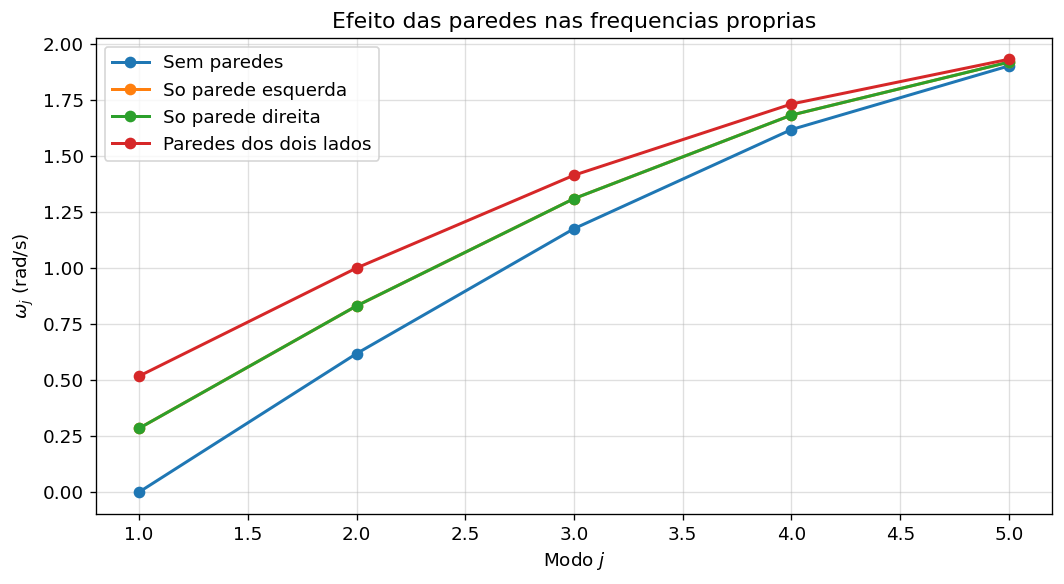

In [10]:
configs = {
    'Sem paredes':            Coupled_Oscillators(N, m=m_val, k_springs=k_val),
    'So parede esquerda':     Coupled_Oscillators(N, m=m_val, k_springs=k_val, left_wall_k=kW),
    'So parede direita':      Coupled_Oscillators(N, m=m_val, k_springs=k_val, right_wall_k=kW),
    'Paredes dos dois lados': osc,
}
fig, ax = plt.subplots(figsize=(9, 5))
for label, sys in configs.items():
    ws, _ = sys.normal_modes()
    ax.plot(np.arange(1, N+1), ws, 'o-', label=label)
ax.set_xlabel('Modo $j$'); ax.set_ylabel('$\\omega_j$ (rad/s)')
ax.set_title('Efeito das paredes nas frequencias proprias')
ax.legend(); plt.tight_layout(); plt.show()

**Análise:** Sem paredes, $\omega_1=0$: modo de **translação rígida** (o sistema pode
deslocar-se em bloco sem restituição). As paredes fornecem restituição nos extremos,
levantando todas as frequências — em especial a mais baixa. Por simetria, uma parede
em qualquer dos lados produz o mesmo levantamento; com paredes dos dois lados o efeito
é maior. Os modos de frequência elevada (com nós nas extremidades) são pouco afectados.

### 4ii) Relação de dispersão — cadeia longa ($N=50$)

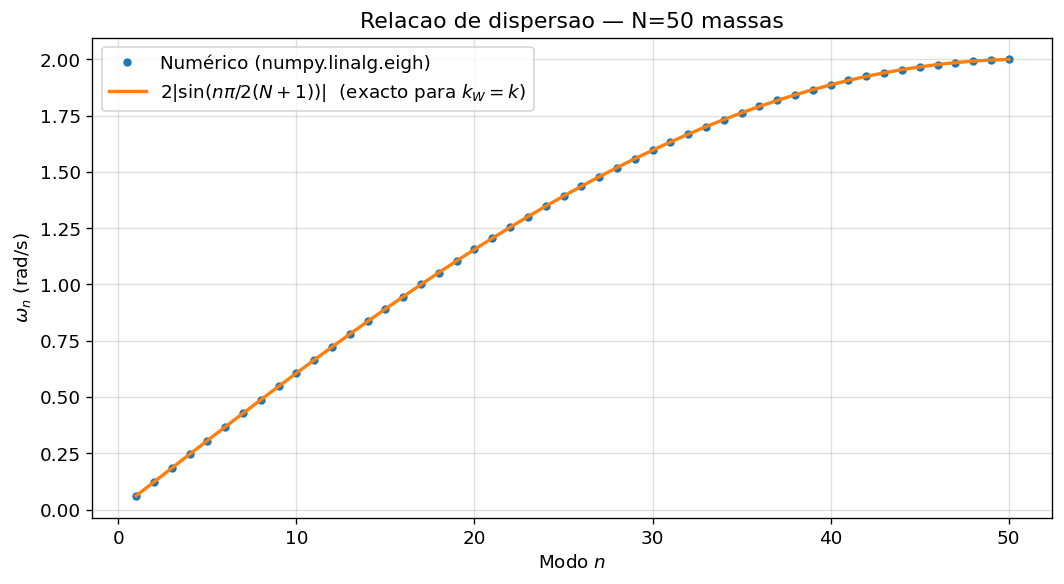

Erro maximo teoria vs numerico: 9.99e-16 rad/s


In [11]:
N_long   = 50
osc_long = Coupled_Oscillators(N_long, m=1.0, k_springs=1.0,
                               left_wall_k=1.0, right_wall_k=1.0)
omegas_long, _ = osc_long.normal_modes()

n = np.arange(1, N_long + 1)
# Exacto para kW = k: K coincide com a submatriz interior de uma cadeia
# de N+2 massas com extremos fixos
omega_theory = 2.0 * np.abs(np.sin(n * np.pi / (2*(N_long+1))))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n, omegas_long,  'o', ms=4, label='Numérico (numpy.linalg.eigh)')
ax.plot(n, omega_theory, '-', lw=2, label=r'$2|\sin(n\pi/2(N+1))|$  (exacto para $k_W=k$)')
ax.set_xlabel('Modo $n$'); ax.set_ylabel('$\\omega_n$ (rad/s)')
ax.set_title(f'Relacao de dispersao — N={N_long} massas')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Erro maximo teoria vs numerico: {np.max(np.abs(omegas_long - omega_theory)):.2e} rad/s')

**Análise:** O acordo entre a fórmula teórica e os valores numéricos é perfeito
(erro $< 10^{-15}$ rad/s, nível de precisão de máquina).

A curva $\omega_n = 2\sqrt{k/m}\,|\sin(n\pi/(2(N+1)))|$ é a **relação de dispersão
discreta**: para $n\ll N$ (comprimentos de onda longos), $\omega_n \propto n$
(regime acústico linear). Para $n\to N$, a discretização da cadeia satura a curva
em $\omega_{\max}=2\sqrt{k/m}$ — o **limite da primeira zona de Brillouin**,
fenómeno sem análogo no contínuo.

### 4iii) Osciladores não-lineares — força cúbica

Adicionamos um termo cúbico à força de cada mola:
$F_{\text{mola}} = k\,\Delta x + \alpha\,(\Delta x)^3$.
Para $\alpha\neq 0$, os modos normais lineares deixam de ser exactos e
observa-se transferência de energia entre modos.

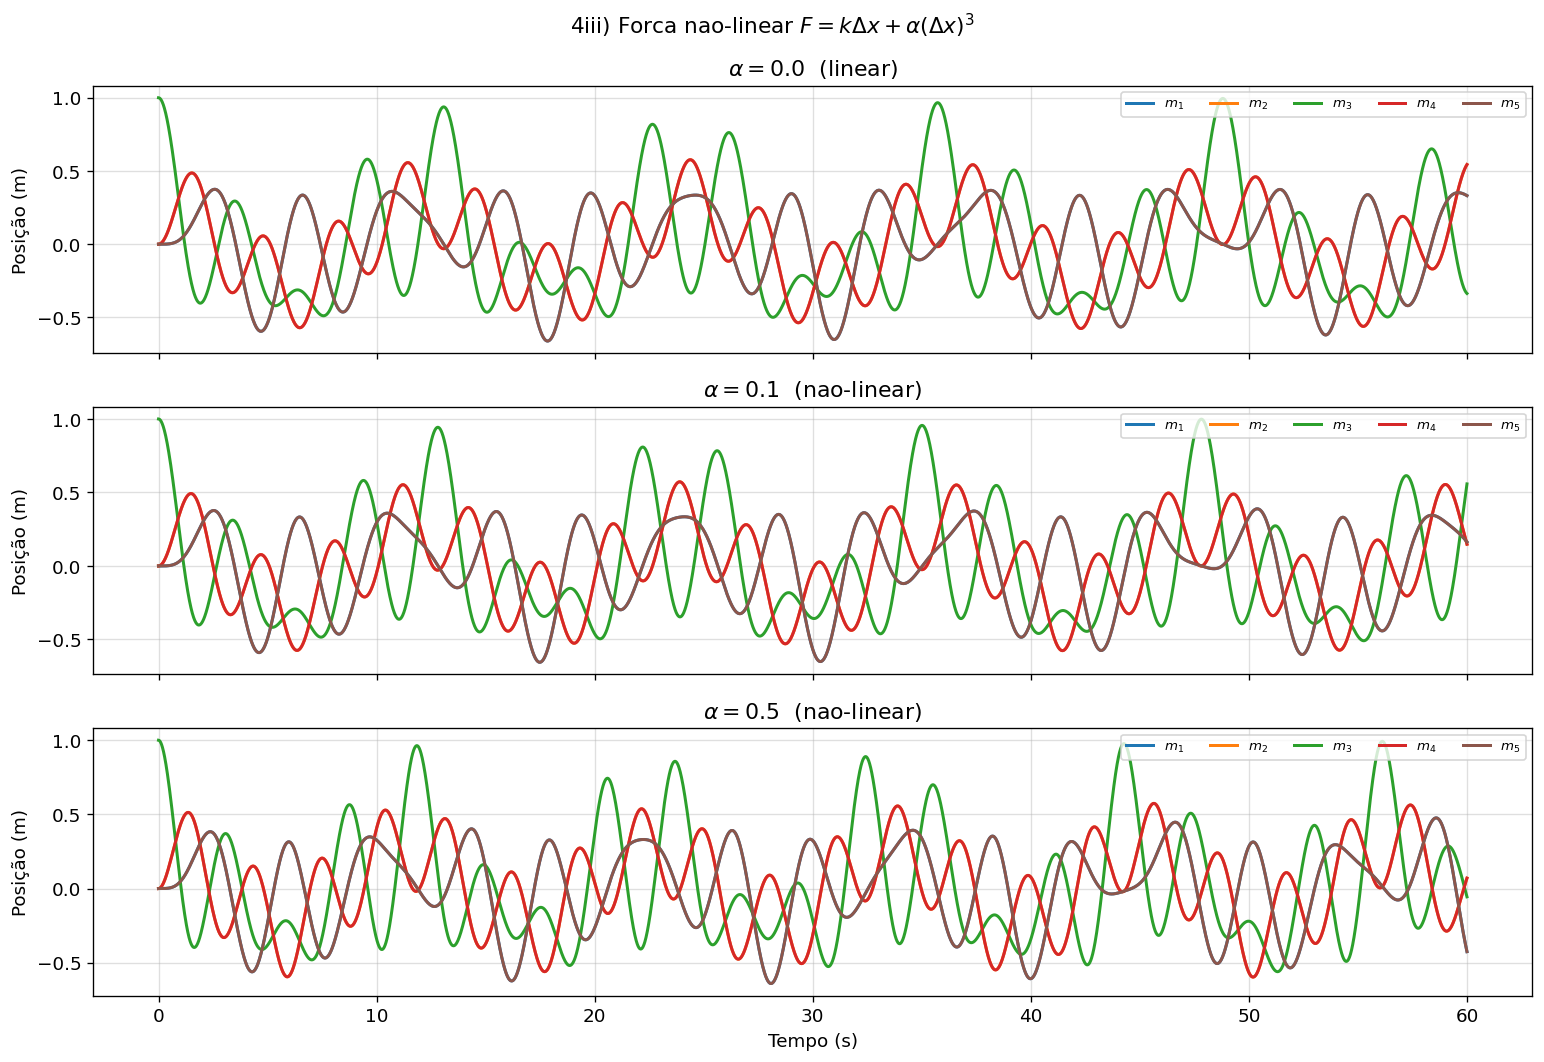

In [12]:
def solve_nonlinear(N, m, k, kW, alpha, x0, v0, t_max, num_points):
    """Integra o sistema nao-linear com forca cubica usando DOP853."""
    t_eval = np.linspace(0, t_max, num_points)
    masses = np.full(N, float(m))
    def dudt(t, u):
        x, v = u[:N], u[N:]
        dx = np.diff(x)
        F  = np.zeros(N)
        f_int = k*dx + alpha*dx**3
        F[:-1] += f_int;  F[1:] -= f_int
        F[0]  -= kW*x[0]  + alpha*x[0]**3
        F[-1] -= kW*x[-1] + alpha*x[-1]**3
        return np.concatenate([v, F/masses])
    sol = solve_ivp(dudt, [0, t_max], np.concatenate([x0, v0]),
                    method='DOP853', t_eval=t_eval, rtol=1e-10, atol=1e-12)
    return sol.t, sol.y

x0_nl = np.zeros(N);  x0_nl[2] = 1.0
v0_nl = np.zeros(N)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, alpha in zip(axes, [0.0, 0.1, 0.5]):
    t_s, u_s = solve_nonlinear(N, m_val, k_val, kW, alpha, x0_nl, v0_nl, t_max, num_points)
    for i in range(N):
        ax.plot(t_s, u_s[i], color=colors[i], label=f'$m_{i+1}$')
    ax.set_ylabel('Posição (m)')
    ax.set_title(f'$\\alpha = {alpha}$  ({"linear" if alpha==0 else "nao-linear"})')
    ax.legend(ncol=5, loc='upper right', fontsize=8)
axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('4iii) Forca nao-linear $F = k\\Delta x + \\alpha (\\Delta x)^3$', fontsize=13)
plt.tight_layout(); plt.show()

**Análise:** Para $\alpha=0$ recupera-se o batimento periódico regular do sistema linear.

Para $\alpha>0$, o acoplamento cúbico torna as frequências efectivas dependentes da
amplitude, quebrando a independência dos modos normais lineares:

- **$\alpha=0.1$**: perturbação fraca — o batimento perde a periodicidade regular;
  a energia redistribui-se de forma irregular entre os modos.
- **$\alpha=0.5$**: perturbação forte — o movimento é claramente irregular.

Este é o problema de **Fermi-Pasta-Ulam** (1955): contrariamente à expectativa de
equipartição de energia (termalização), observa-se **recorrência quase-periódica** —
a energia retorna periodicamente ao modo inicialmente excitado. Este resultado inesperado
abriu o estudo moderno de sistemas não-lineares e integrabilidade.